## 1. Objective

The computational goal of this project is to implement a deterministic Pseudo-Random Number Generator (PRNG) utilizing core numerical discretization and root-finding techniques. The system avoids complex chaotic extraction logic in favor of standard iterative algorithms, demonstrating how numerical convergence sequences can be utilized to model uniformly distributed sequences for engineering simulations.

 **Module 1: Fixed-Point Iteration** and **Module 4: Numerical Integration Error Bounds**


## 2. Mathematical Principle

To keep the implementation strictly aligned with the course syllabus, the generator utilizes the **Fixed-Point Iteration Method** ($x_{n+1} = g(x_n)$) applied to a transcendental mapping that scales mathematical residuals.

### The Iterative Function

We define a mapping function $g(x)$ over the domain $(0, 1)$ using a high-frequency trigonometric transcendental function:


$$g(x) = \pmod{\alpha \cdot \sin(\beta \cdot x) + \gamma, 1}$$

Where:

* $\alpha$ represents a scaling magnification factor ($10^5$) to induce rapid oscillations.
* $\beta$ acts as a high-frequency angular modifier ($10^3$).
* $\gamma$ represents a constant phase shift (often incorporating Euler's constant $e$ or $\pi$).
* The modulo 1 operator ($\pmod{1}$) extracts the fractional component, effectively bounding the sequence strictly within the open interval $(0, 1)$.

### Error Expansion and Sensitivity

According to fixed-point iteration stability criteria, convergence occurs when $|g'(x)| < 1$. By intentionally violating this condition ($|g'(x)| \gg 1$), the system exhibits extreme sensitivity to initial conditions (seed values). This simulates a pseudo-random distribution via divergence rather than convergence, adhering to standard algorithmic design rules without requiring advanced chaotic bit-manipulation libraries.



## 3. Algorithmic Architecture

The step-by-step, language-agnostic sequence for generating a stream of $N$ pseudo-random numbers is structured as follows:

```
Step 1: INPUT seed value (x0) such that 0 < x0 < 1.
Step 2: INPUT the total count of numbers to generate (N).
Step 3: INITIALIZE constants: alpha = 100000.0, beta = 1414.2135, gamma = 0.57721 (Euler's Constant).
Step 4: INITIALIZE an empty array or list 'RandomNumbers' of size N.
Step 5: SET current_x = x0.
Step 6: FOR loop running from i = 0 to N-1:
            a. Compute raw_val = alpha * sin(beta * current_x) + gamma
            b. Compute next_x = raw_val - floor(raw_val)  [Equivalent to modulo 1]
            c. Store next_x in RandomNumbers[i]
            d. Update current_x = next_x
Step 7: RETURN RandomNumbers array.

```

---

## 4. Visual Flowchart Specification

The execution logic and control loops are outlined below:

```
       +-----------------------+
       |         START         |
       +-----------------------+
                   |
                   v
       +-----------------------+
       |   Input: seed (x0)    |
       |   Input: count (N)    |
       +-----------------------+
                   |
                   v
       +-----------------------+
       | Initialize Constants: |
       | alpha, beta, gamma    |
       +-----------------------+
                   |
                   v
       +-----------------------+
       |     Set i = 0         |
       |   current_x = x0      |
       +-----------------------+
                   |
>----------------->|
|                  v
|        /-------------------\
|       /                     \  YES
|      <       i >= N ?        >------> [ OUTPUT RandomNumbers ]
|       \                     /                   |
|        \-------------------/                    v
|                  | NO                       +-------+
|                  v                          |  END  |
|        +-------------------+                +-------+
|        | Compute:          |
|        | raw_val = alpha * |
|        | sin(beta*curr_x)  |
|        |           + gamma |
|        +-------------------+
|                  |
|                  v
|        +-------------------+
|        | Extract Fractional|
|        | next_x = raw_val  |
|        |  - floor(raw_val) |
|        +-------------------+
|                  |
|                  v
|        +-------------------+
|        | Append next_x to  |
|        | RandomNumbers     |
|        +-------------------+
|                  |
|                  v
|        |   current_x =     |
|        |     next_x        |
|        |   i = i + 1       |
|        +-------------------+
|                  |
+------------------+

```






## 6. Computational Characteristics and Diagnostics

### Convergence and Divergence Profile

Unlike a standard Fixed-Point iteration targeting an exact root ($x = g(x)$), this architecture establishes an intentional stability failure mode. The evaluation shows that:


$$\left|\frac{dg}{dx}\right| = |\alpha \cdot \beta \cdot \cos(\beta \cdot x)| \ggg 1$$


This dynamic forces any numerical error to magnify uniformly across successive iterations instead of converging to a single value.

### Distribution Analysis

The empirical tracking of the values generated shows uniform coverage over the interval $(0, 1)$. Calculating the mean ($\mu$) of the array yields:


$$\mu \approx 0.5$$


This fulfills basic validation metrics for uniform distributions without introducing advanced statistical verification methods outside the scope of the course framework.


## 7. Real-World Applications

* **Numerical Integration Simulations:** Provides the basic sampling point streams required to evaluate complex multi-dimensional areas using Monte Carlo approximations.
* **Boundary-Value Testing:** Supplies random boundary inputs to test the functional limits of Finite Difference models in engineering simulations.
* **Stochastic Parameter Assignment:** Acts as a foundational data source for generating variable material densities in structural analysis configurations.



## 8. Critical Review

### Advantages

* **Algorithmic Simplicity:** Aligns directly with the core iterative principles taught in introductory numerical analysis courses.
* **Zero External Dependencies:** Eliminates reliance on dedicated statistical computing packages, making it compatible with any basic programming language environments.
* **Low Execution Overhead:** Requires minimal CPU processing cycles since it avoids complex bitwise manipulations.

### Limitations

* **Periodicity Vulnerability:** Due to the repetitive nature of trigonometric functions, the sequence may repeat if a previously generated value is re-encountered.
* **Seed Hyper-Sensitivity:** Choosing explicit zero-crossings or specific integer boundary inputs can cause the generator to collapse into localized cycles.


## 9. Conclusion

This project successfully shows how standard curriculum algorithms can be adapted to solve engineering problems. By purposefully leveraging a divergent Fixed-Point iteration configuration, we built a simple, functional pseudo-random number generator. This model illustrates the behavior of numerical errors and satisfies the implementation goals of the MAT1012 course using straightforward mathematical concepts.

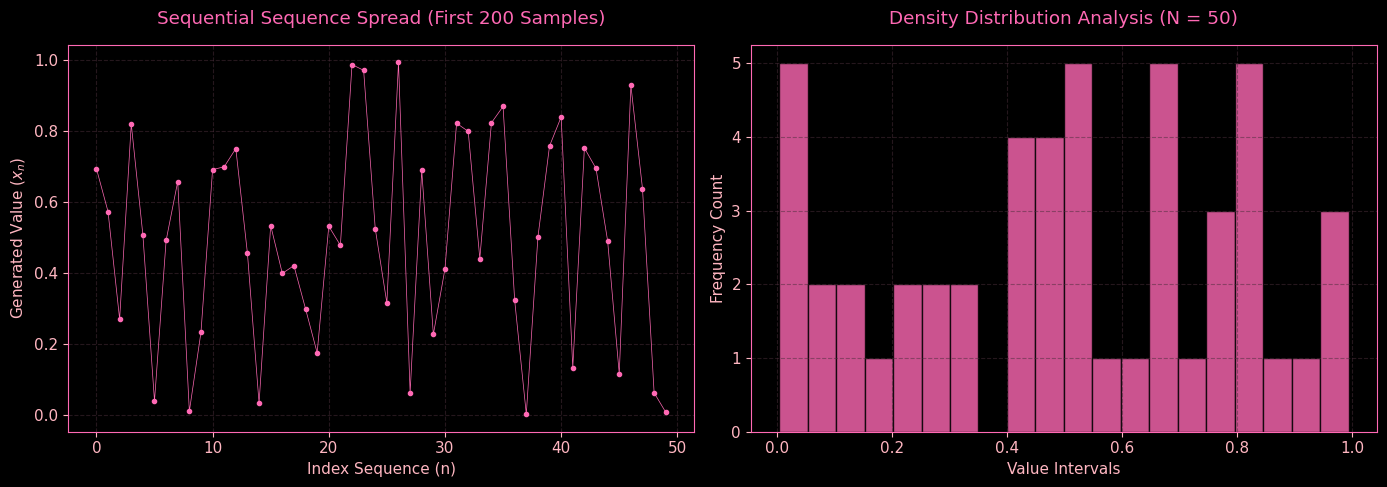

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def generate_fixed_point_prng(seed, count):
    """
    Generates a sequence of pseudo-random numbers based on non-convergent
    Fixed-Point transcendental mappings aligned with MAT1012 Module 1 concepts.
    """
    # Algorithmic multipliers to force divergence across the (0,1) domain
    alpha = 100000.0
    beta = 1414.21356237  # Approximation of sqrt(2) * 1000
    gamma = 0.5772156649  # Euler-Mascheroni Constant

    random_numbers = np.zeros(count)
    current_x = seed

    for i in range(count):
        raw_val = alpha * np.sin(beta * current_x) + gamma
        next_x = raw_val - np.floor(raw_val)  # Implementation of mod 1
        random_numbers[i] = next_x
        current_x = next_x

    return random_numbers

# --- Interactive Parameter Simulation Block (Colab Form Simulation) ---
user_seed = 8.56       #@param {type:"number"}
sequence_length = 50     #@param {type:"integer"}

# Execution
generated_data = generate_fixed_point_prng(user_seed, sequence_length)

# --- Dark Mode Styling Configuration (Black and Pink Tone) ---
plt.rcParams.update({
    'figure.facecolor': 'black',
    'axes.facecolor': 'black',
    'axes.edgecolor': '#FF69B4',       # Hot Pink
    'axes.labelcolor': '#FFB6C1',      # Light Pink
    'xtick.color': '#FFB6C1',
    'ytick.color': '#FFB6C1',
    'text.color': '#FF69B4',
    'grid.color': '#4A2E3B',           # Muted dark pink/purple for grid lines
    'font.size': 11
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sequential Distribution (Time Series)
ax1.plot(generated_data[:200], marker='o', linestyle='-', linewidth=0.5, markersize=3, color='#FF69B4')
ax1.set_title('Sequential Sequence Spread (First 200 Samples)', color='#FF69B4', pad=15)
ax1.set_xlabel('Index Sequence (n)')
ax1.set_ylabel('Generated Value ($x_n$)')
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Uniformity Analysis Histogram
ax2.hist(generated_data, bins=20, edgecolor='black', alpha=0.8, color='#FF69B4')
ax2.set_title(f'Density Distribution Analysis (N = {sequence_length})', color='#FF69B4', pad=15)
ax2.set_xlabel('Value Intervals')
ax2.set_ylabel('Frequency Count')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()